In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [2]:
# Import All Dataset

import pickle

with open("allDataset.pkl", "rb") as f:
  allDataset = pickle.load(f)

In [3]:
print(allDataset.shape)
print(allDataset.keys())

(6894, 36)
Index(['background_father', 'background_mother', 'age', 'gender', 'smoke',
       'drink', 'skin_cancer_history', 'cancer_history', 'pesticide',
       'biopsed', 'grew', 'hurt', 'bleed', 'itch', 'elevation', 'changed',
       'diameter_1', 'diameter_2', 'has_sewage_system', 'has_piped_water',
       'race', 'img_id', 'diagnostic', 'region_ARM', 'region_BACK',
       'region_CHEST', 'region_EAR', 'region_FACE', 'region_FOOT',
       'region_FOREARM', 'region_HAND', 'region_LIP', 'region_NECK',
       'region_NOSE', 'region_SCALP', 'region_THIGH'],
      dtype='object')


In [4]:
# Get Imgs + Labels

imgs = []
labels = []

for i in range(len(allDataset)):
  image = cv2.imread(allDataset["img_id"][i])
  image_resize = cv2.resize(image, (128, 128))
  imgs.append(image_resize)
  labels.append(allDataset["diagnostic"][i])

In [14]:
# Split The Data

from sklearn.model_selection import train_test_split
tempImgs = np.array(imgs)
tempLabels = np.array(labels)

x_train, x_test, y_train, y_test = train_test_split(tempImgs, tempLabels, test_size = 0.3, random_state = 42)

In [15]:
# Images Normalization

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [16]:
# Labels OneHotEncoding

from sklearn.preprocessing import LabelEncoder

labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)
y_test = labelEncoder.transform(y_test)
print(labelEncoder.classes_)

orderLabels = labelEncoder.classes_

print(labelEncoder.classes_[0])

['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
ACK


(4825, 128, 128, 3)
(2069, 128, 128, 3)


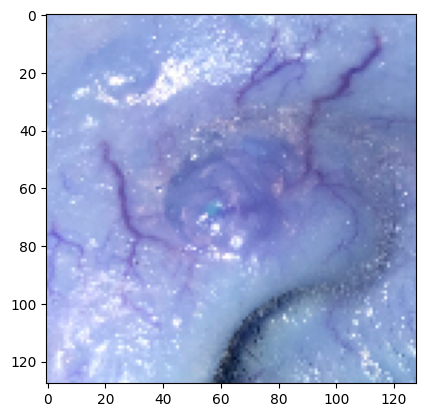

In [17]:
print(x_train.shape)
print(x_test.shape)

plt.imshow(x_train[0])

In [18]:
import tensorflow as tf
from tensorflow.keras import models, layers, Model
from tensorflow.keras.models import Sequential
# from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [19]:
# Transfer Learning Model

base_model = Sequential()
base_model.add(MobileNet(input_shape = (128, 128, 3), include_top = False, weights = "imagenet", pooling = "max"))
base_model.add(layers.Dense(128, activation = "relu"))
base_model.add(layers.Dense(64, activation = "relu"))
base_model.add(layers.Dense(6, activation = "softmax"))

In [20]:
base_model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

checkPoint = ModelCheckpoint("best_model.keras", monitor = "val_accuracy")
earlyStopping = EarlyStopping(monitor = "val_accuracy", patience = 5, restore_best_weights = True)

hist = base_model.fit(x_train, y_train, epochs = 50, validation_split = 0.2, batch_size = 128, callbacks = [checkPoint, earlyStopping])

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 0.5163 - loss: 1.6070 - val_accuracy: 0.3368 - val_loss: 1.6212
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 162s 5s/step - accuracy: 0.7427 - loss: 0.6978 - val_accuracy: 0.4114 - val_loss: 1.5825
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 159s 5s/step - accuracy: 0.8593 - loss: 0.3903 - val_accuracy: 0.4601 - val_loss: 1.5558
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 163s 5s/step - accuracy: 0.9329 - loss: 0.2019 - val_accuracy: 0.3876 - val_loss: 2.0293
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 183s 6s/step - accuracy: 0.9593 - loss: 0.1271 - val_accuracy: 0.4715 - val_loss: 2.2377
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 157s 5s/step - accuracy: 0.9402 - loss: 0.1854 - val_accuracy: 0.5181 - val_loss: 1.9365
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 161s 5s/step - accuracy: 0.9078 - loss: 0.2756 - val_accuracy: 0.5782 - val_loss: 1.3710
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 156s 5s/step - accuracy: 0.9324 - loss: 0.1900 - val_accuracy: 0.5202 - v

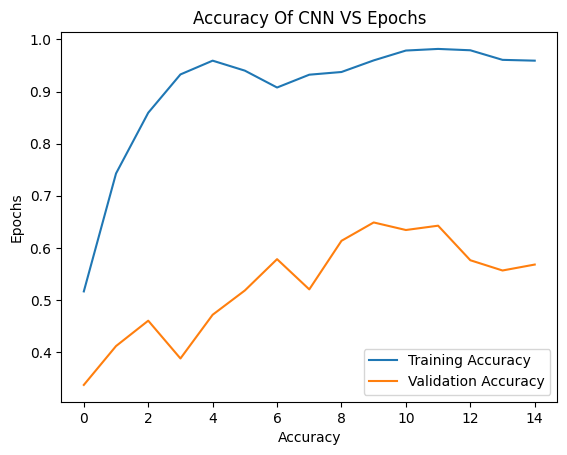

In [22]:
# Accuracy Visualization

plt.plot(hist.history["accuracy"], label = "Training Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Accuracy Of CNN VS Epochs")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")

plt.legend()
plt.show()

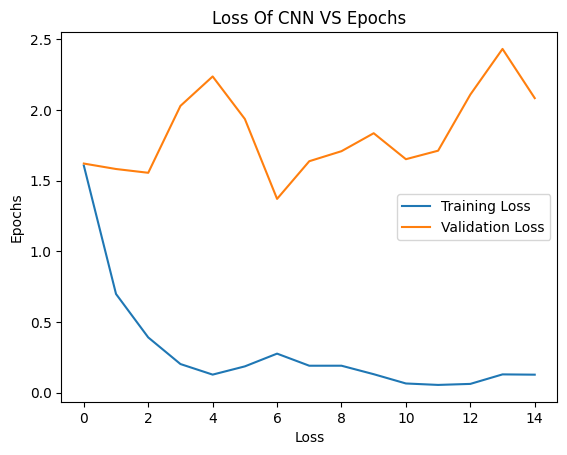

In [23]:
# Loss Visualization

plt.plot(hist.history["loss"], label = "Training Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")

plt.title("Loss Of CNN VS Epochs")
plt.xlabel("Loss")
plt.ylabel("Epochs")

plt.legend()
plt.show()

In [24]:
base_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_128 (Functional) │ (None, 1024)           │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,062,356 (38.38 MB)

 Trainable params: 3,346,822 (12.77 MB)

 Non-trainable params: 21,888 (85.50 KB)

 Optimizer params: 6,693,646 (25.53 MB)

In [25]:
# Evaluate The model

model_loss, model_accuracy = base_model.evaluate(x_test, y_test)

print(f"Model Loss {model_loss}")
print(f"Model Accuracy {model_accuracy}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - accuracy: 0.6423 - loss: 1.7205
Model Loss 1.7204596996307373
Model Accuracy 0.642339289188385


In [26]:
# Save Model

base_model.save("cnn_tf_model.keras")

In [27]:
# Export Labels' Dictionary, Train, Test

import pickle

with open("orderLabels.pkl", "wb") as f:
  pickle.dump(orderLabels, f)

with open("x_train_cnn.pkl", "wb") as f:
  pickle.dump(x_train, f)

with open("y_train_cnn.pkl", "wb") as f:
  pickle.dump(y_train, f)

with open("x_test_cnn.pkl", "wb") as f:
  pickle.dump(x_test, f)

with open("y_test_cnn.pkl", "wb") as f:
  pickle.dump(y_test, f)